In [1]:
import os
os.environ["DB_PASSWORD"] = "Jan@07wed"

# Import Required Libraries

Load necessary Python packages for data analysis and visualization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import mysql.connector
import warnings
warnings.filterwarnings('ignore')


# Load Historical Stock Data

Connect to MySQL and read 5-year stock tables for four companies.

In [3]:
import os

password = os.getenv("DB_PASSWORD")

if password is None:
    raise ValueError("Database password not set")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=password,
    database="stockprice"
)

infy = pd.read_sql("select * from infy_5y", conn)
wipro = pd.read_sql("select * from wipro_5y", conn)
tcs = pd.read_sql("select * from tcs_5y", conn)
hcl = pd.read_sql("select * from hcltech_5y", conn)

print('Infosys dataset length:', infy.shape[0])
print('Wipro dataset length:', wipro.shape[0])
print('TCS dataset length:', tcs.shape[0])
print('HCL dataset length:', hcl.shape[0])

Infosys dataset length: 1237
Wipro dataset length: 1237
TCS dataset length: 1237
HCL dataset length: 1237


# Data Cleaning and Preprocessing

Standardize stock datasets, fix types, and prepare a multi-index time series.

In [4]:
# Add company column
infy['Company'] = 'INFY'
wipro['Company'] = 'WIPRO'
tcs['Company'] = 'TCS'
hcl['Company'] = 'HCL'

# Combine all datasets
stock_data = pd.concat([tcs, infy, wipro, hcl], ignore_index=True)

# Convert Date
stock_data['Date'] = pd.to_datetime(stock_data['Date'], errors='coerce')

# Drop nulls
stock_data.dropna(subset=['Date', 'Close'], inplace=True)

# Convert numeric columns
cols = ['Open','High','Low','Close','Volume']
for col in cols:
    stock_data[col] = pd.to_numeric(stock_data[col], errors='coerce')

# Sort properly
stock_data = stock_data.sort_values(by=['Company','Date'])

# Remove duplicates
stock_data.drop_duplicates(subset=['Company','Date'], inplace=True)

# Set index
stock_data = stock_data.set_index(['Company','Date'])

# Execute SQL Queries on Imported Datasets

Engineer returns and compute company-specific metrics from the combined dataset.

In [5]:
# Feature Engineering
stock_data['Daily_Return'] = stock_data.groupby('Company')['Close'].pct_change()

# Analytics Functions
def to_percent(val):
    if isinstance(val, (int, float)):
        return f"{val:.2%}"
    return val

def get_individual_stats(df, ticker):
    ticker_df = df.loc[ticker].copy()
    adj_close = ticker_df['Close']

    stats = {
        "Volatility (Annual)": ticker_df['Daily_Return'].dropna().std() * np.sqrt(252),
        "Daily Return (Avg)": ticker_df['Daily_Return'].mean(),
        "Weekly Return": adj_close.resample('W').last().pct_change().iloc[-1],
        "Monthly Return": adj_close.resample('ME').last().pct_change().iloc[-1],
        "Quarterly Return": adj_close.resample('QE').last().pct_change().iloc[-1],
        "Annual Return": adj_close.resample('YE').last().pct_change().iloc[-1],
        "5-Year Return": (adj_close.iloc[-1] / adj_close.iloc[0] - 1)
    }

    return pd.Series({k: to_percent(v) for k, v in stats.items()})

# Individual Analysis
companies = stock_data.index.levels[0]

individual_report = pd.DataFrame({
    company: get_individual_stats(stock_data, company)
    for company in companies
})

print("\nIndividual Stock Report:\n")
print(individual_report)


Individual Stock Report:

                         HCL      TCS   WIPRO
Volatility (Annual)   24.08%   20.77%  25.86%
Daily Return (Avg)     0.08%    0.03%   0.05%
Weekly Return          1.97%    1.13%   1.37%
Monthly Return         3.11%    5.78%   7.43%
Quarterly Return      21.87%   15.34%  11.99%
Annual Return         -9.34%  -16.13%  -7.65%
5-Year Return        121.52%   26.82%  48.07%


# Perform Stock Analysis

Calculate total growth, risk, and Sharpe ratios to identify the best stock.

In [6]:
# Combined Analysis

# Total growth
total_growth = stock_data.groupby(level='Company')['Close'].apply(lambda x: (x.iloc[-1] / x.iloc[0]) - 1)

# Risk (volatility)
risk = stock_data.groupby(level='Company')['Daily_Return'].std() * np.sqrt(252)

# Sharpe ratio
sharpe = total_growth / risk

recommended = sharpe.idxmax()

print(f"\nRecommended Stock: {recommended} (Best Risk-Adjusted Return)")


Recommended Stock: HCL (Best Risk-Adjusted Return)


# Generate Visualizations

Create price, returns, moving average, and candlestick charts for each stock.

In [7]:
# Visualization Functions

def showPriceTrendChart(data, title):
    plt.figure()
    plt.plot(data.index, data['Close'])
    plt.title(f"{title} Price Trend")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.show()

def showReturnsHist(data, title):
    data = data['Daily_Return'].dropna()
    sns.histplot(data, bins=100, kde=True)
    plt.axvline(data.mean(), linestyle='--', label=f'Mean: {data.mean():.2%}')
    plt.title(f'Daily Returns Distribution: {title}')
    plt.legend()
    plt.show()

def showMA(data, title):
    plt.figure(figsize=(10,5))
    plt.plot(data['MA20'], label='20-Day MA')
    plt.title(f'{title} Moving Average')
    plt.legend()
    plt.show()

def showCandleStickChart(data, title):
    fig = go.Figure(data=[go.Candlestick(
        x=data.index,
        open=data['Open'],
        high=data['High'],
        low=data['Low'],
        close=data['Close']
    )])
    fig.update_layout(title=f'{title} Candlestick Chart')
    fig.show()

def showCandleStickWithVolumeGraph(df, title):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close']
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=df.index,
        y=df['Volume']
    ), row=2, col=1)

    fig.update_layout(title=f'{title} Price & Volume')
    fig.show()

# Export Results

Produce final comparison plots and correlation analysis across all stocks.

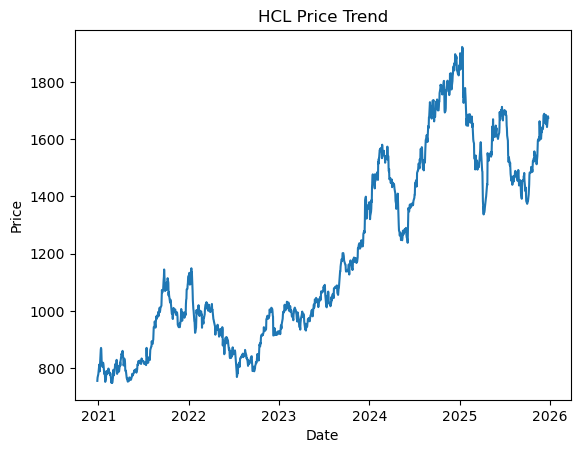

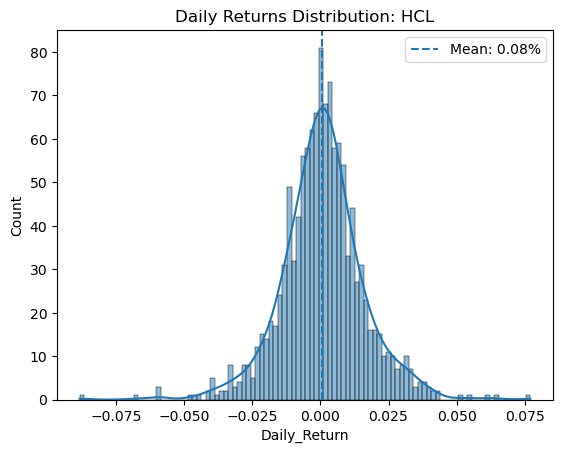

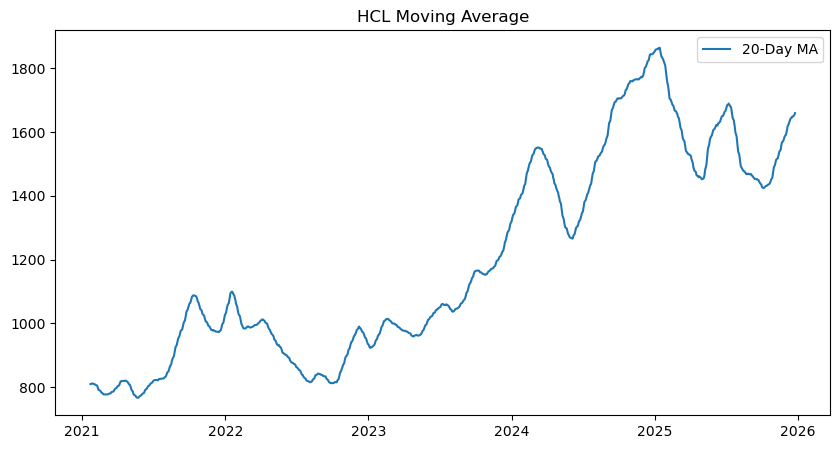

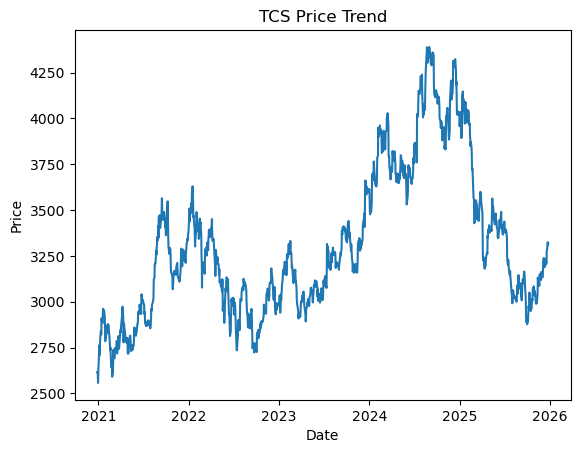

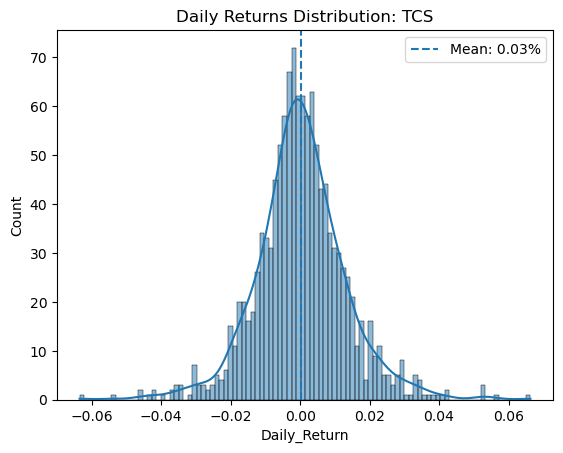

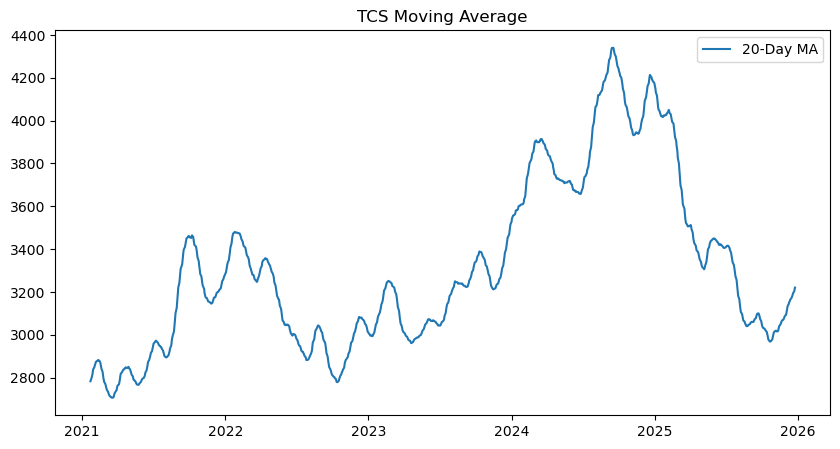

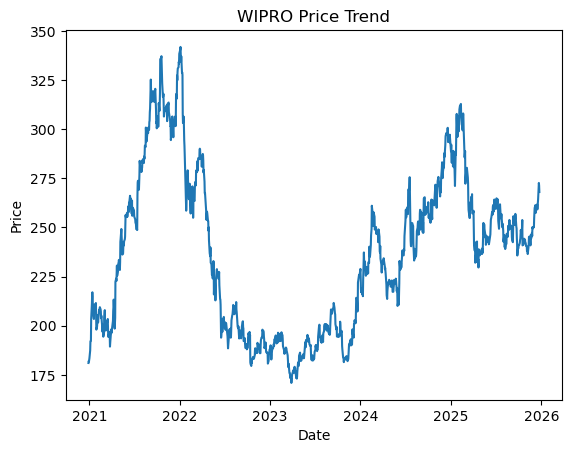

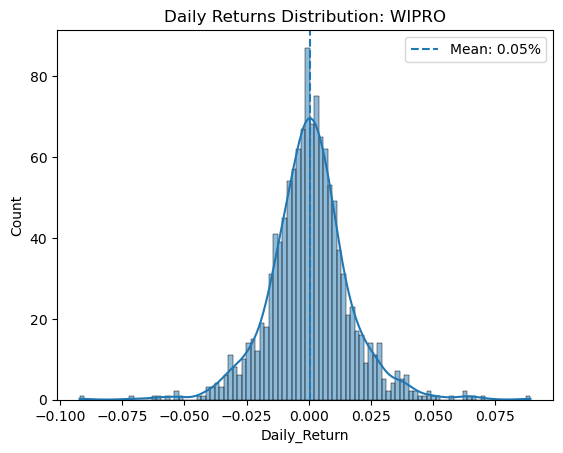

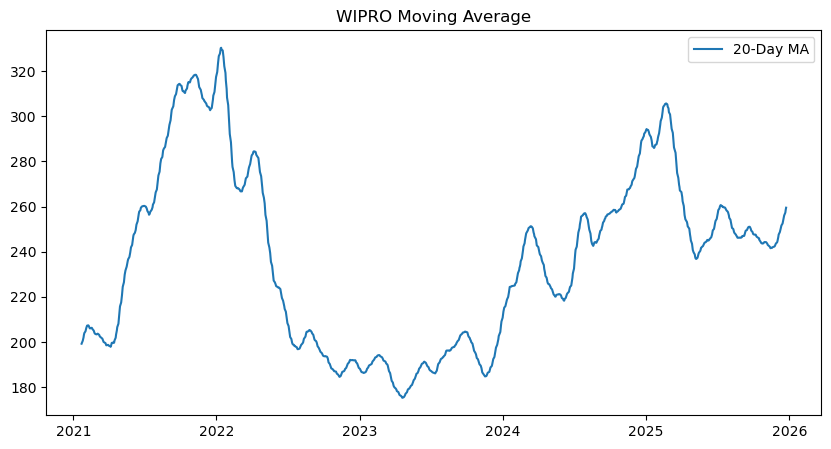

In [8]:
# Loop-based Visualization

for company in companies:
    df = stock_data.loc[company].copy()

    showPriceTrendChart(df, company)

    showReturnsHist(df, company)

    # Moving average
    df['MA20'] = df['Close'].rolling(20).mean()
    showMA(df, company)

    # Last 6 months candlestick
    latest_date = df.index.max()
    six_months_ago = latest_date - pd.DateOffset(months=6)

    df_6m = df[df.index >= six_months_ago].copy()
    showCandleStickChart(df_6m, company)

    showCandleStickWithVolumeGraph(df, company)

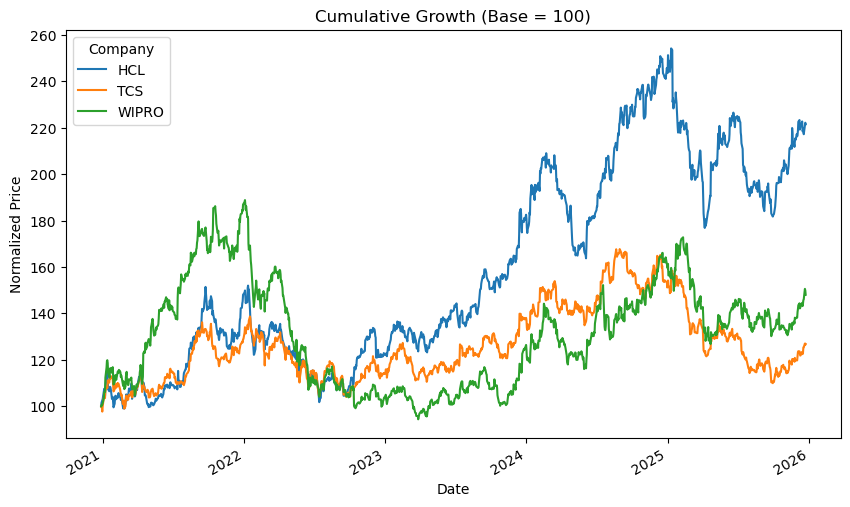

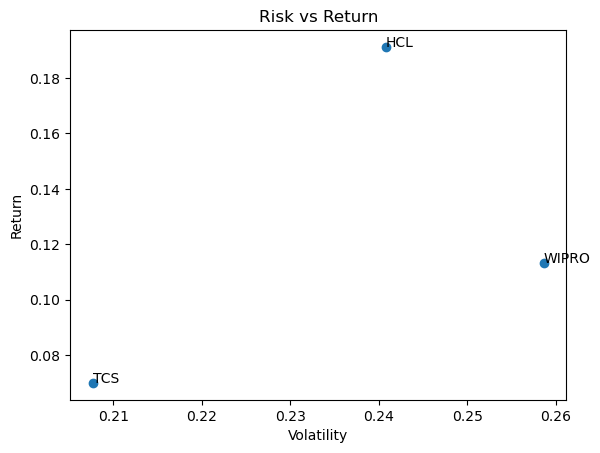

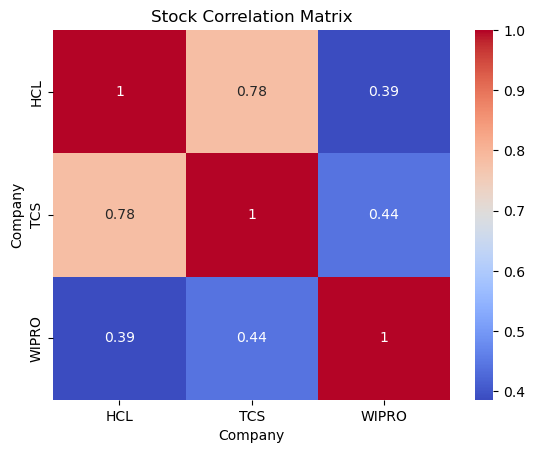

In [9]:
# Combined Visualizations

# Normalized growth comparison
normalized = stock_data.groupby('Company')['Close'].transform(lambda x: (x / x.iloc[0]) * 100)

normalized.unstack(level='Company').plot(figsize=(10,6))
plt.title('Cumulative Growth (Base = 100)')
plt.ylabel('Normalized Price')
plt.show()

# Risk vs Return Scatter Plot
stats = stock_data.groupby('Company')['Daily_Return'].agg(['mean', 'std'])
stats['Annual_Return'] = stats['mean'] * 252
stats['Annual_Volatility'] = stats['std'] * np.sqrt(252)

plt.scatter(stats['Annual_Volatility'], stats['Annual_Return'])

for company in stats.index:
    plt.annotate(company, 
        (stats.loc[company, 'Annual_Volatility'],
         stats.loc[company, 'Annual_Return']))

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Risk vs Return")
plt.show()

# Correlation Heatmap
pivot = stock_data.reset_index().pivot(index='Date', columns='Company', values='Close')

sns.heatmap(pivot.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Correlation Matrix")
plt.show()